# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix
from sklearn.tree import DecisionTreeClassifier


# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/9790bb95f081a8b85d75fa46ac19fa39ca3f88a6/11.%20%20Decision%20Tree/data/heart_disease.xlsx"
excel_file = pd.ExcelFile(url)

In [3]:
excel_file.sheet_names

['Description', 'Heart_disease']

In [4]:
df = pd.read_excel(excel_file,sheet_name = "Heart_disease")

# Preview of the Dataset

In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


# Initial Data Understanding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


## Dataset Dimensions

In [7]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (908, 13)
Size :  11804


## Check DataTypes

In [8]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64


# Data Cleaning

## Cleaning `exang` Column

In [9]:
df["exang"].value_counts()

,count
exang,
False,516
True,337
TURE,36
FALSE,19


In [10]:
df["exang"] = df["exang"].replace("TURE",True)
df["exang"] = df["exang"].replace("FALSE",False)

/tmp/ipykernel_2130/2113929499.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["exang"] = df["exang"].replace("FALSE",False)


In [11]:
df["exang"].value_counts()

,count
exang,
False,535
True,373


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    bool   
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(2), float64(1), int64(5), object(5)
memory usage: 79.9+ KB


## Checking Duplicate Records

In [13]:
print("No.of Duplicate Records : ",df.duplicated().sum())

No.of Duplicate Records :  1


## Checking Missing Values

In [14]:
clean_cat_cols = df.select_dtypes(include="object").columns
df[clean_cat_cols] = df[clean_cat_cols].apply(lambda x: x.str.strip())

In [15]:
print("No.of Missing Values : ")
print(df.isnull().sum())

No.of Missing Values : 
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [16]:
print("No.of Missing Value Percentage : ")
print(((df.isnull().sum()/len(df))*100).sort_values(ascending = False))

No.of Missing Value Percentage : 
oldpeak     6.828194
sex         0.000000
cp          0.000000
trestbps    0.000000
age         0.000000
chol        0.000000
fbs         0.000000
thalch      0.000000
restecg     0.000000
exang       0.000000
slope       0.000000
thal        0.000000
num         0.000000
dtype: float64


## Removing Duplicate Records and Treating Missing Values

In [17]:
df.drop_duplicates(inplace = True)

In [18]:
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

In [19]:
print("No.of Duplicate Records after Removal : ",df.duplicated().sum())
print("No.of Missing Values : ")
print(df.isnull().sum())

No.of Duplicate Records after Removal :  0
No.of Missing Values : 
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


# Descriptive Statistical Analysis

In [20]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,53.787211,133.412348,201.465270,135.976847,0.865491,1.007718
std,9.162016,20.405432,112.158285,26.813075,1.060629,1.144594
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [21]:
print("Mode : \n",df.mode().iloc[0])

Mode : 
 age                        54
sex                      Male
cp               asymptomatic
trestbps                  120
chol                        0
fbs                     False
restecg                normal
thalch                    140
exang                   False
oldpeak                   0.0
slope                    flat
thal        reversable defect
num                         0
Name: 0, dtype: object


## Observation

The numerical variables show considerable variation, particularly cholesterol (chol), while some values such as trestbps and chol having 0 may indicate potential data inconsistencies. The target variable num ranges from 0 to 4, confirming that this is a multiclass classification problem. The mode shows that the most frequently occurring observations belong to class 0, indicating a possible class imbalance in the dataset.

# Exploratory Data Analysis

In [22]:
Categorical_cols = df.select_dtypes(include=["object","bool"]).columns
Numerical_cols = df.select_dtypes(include = np.number).columns
print("Categorical Columns : \n",Categorical_cols)
print("="*100)
print("Numerical Columns : \n",Numerical_cols)

Categorical Columns : 
 Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')
Numerical Columns : 
 Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')


## Boxplot Analysis

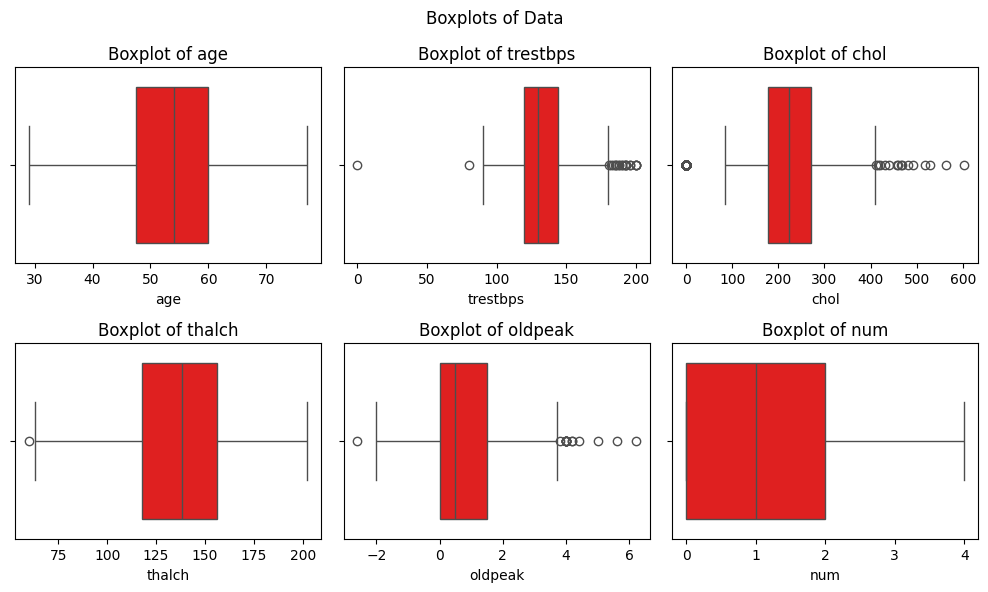

In [23]:
fig,ax = plt.subplots(2,3,figsize=(10,6))

for axis,col in zip(ax.flat,Numerical_cols):
  sns.boxplot(data=df,x=col,ax=axis,color="red")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)

plt.suptitle("Boxplots of Data")
plt.tight_layout()
plt.show()

### Observation

Most numerical features show the presence of some outliers, particularly chol, trestbps, and oldpeak. The chol variable has several high-value outliers, while oldpeak also contains extreme values. The target variable num does not show significant outliers because it represents discrete classes from 0 to 4.

## Histogram Analysis

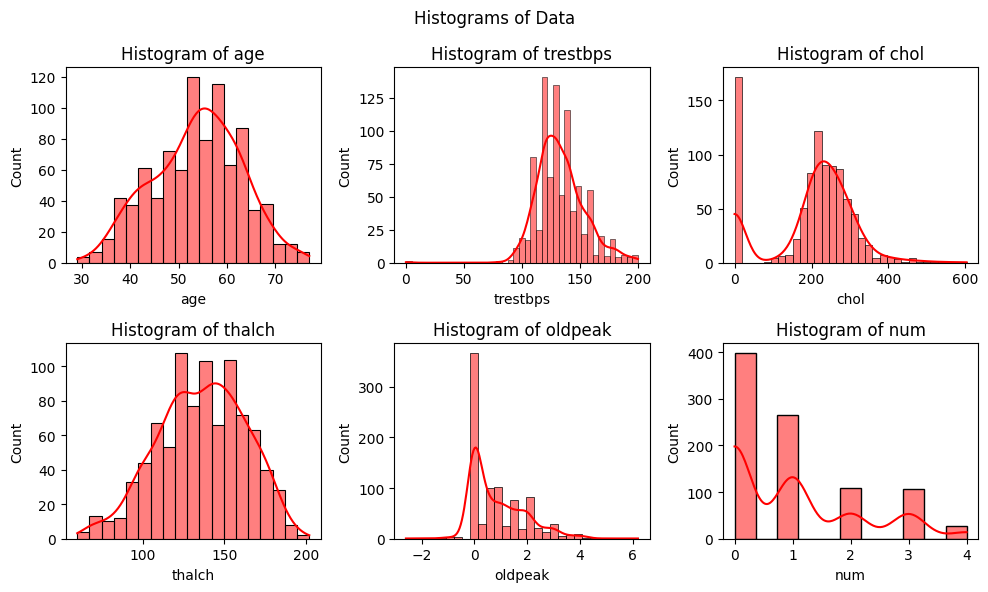

In [24]:
fig,ax = plt.subplots(2,3,figsize=(10,6))

for axis,col in zip(ax.flat,Numerical_cols):
  sns.histplot(data=df,x=col,ax=axis,color="red",kde=True)
  axis.set_title(f"Histogram of {col}")
  axis.set_xlabel(col)

plt.suptitle("Histograms of Data")
plt.tight_layout()
plt.show()

### Observation

Most numerical features show approximately concentrated distributions around their central values. chol and oldpeak appear skewed and contain extreme values, while the target variable num shows an imbalanced class distribution, with class 0 occurring most frequently.

## Countplot Analysis

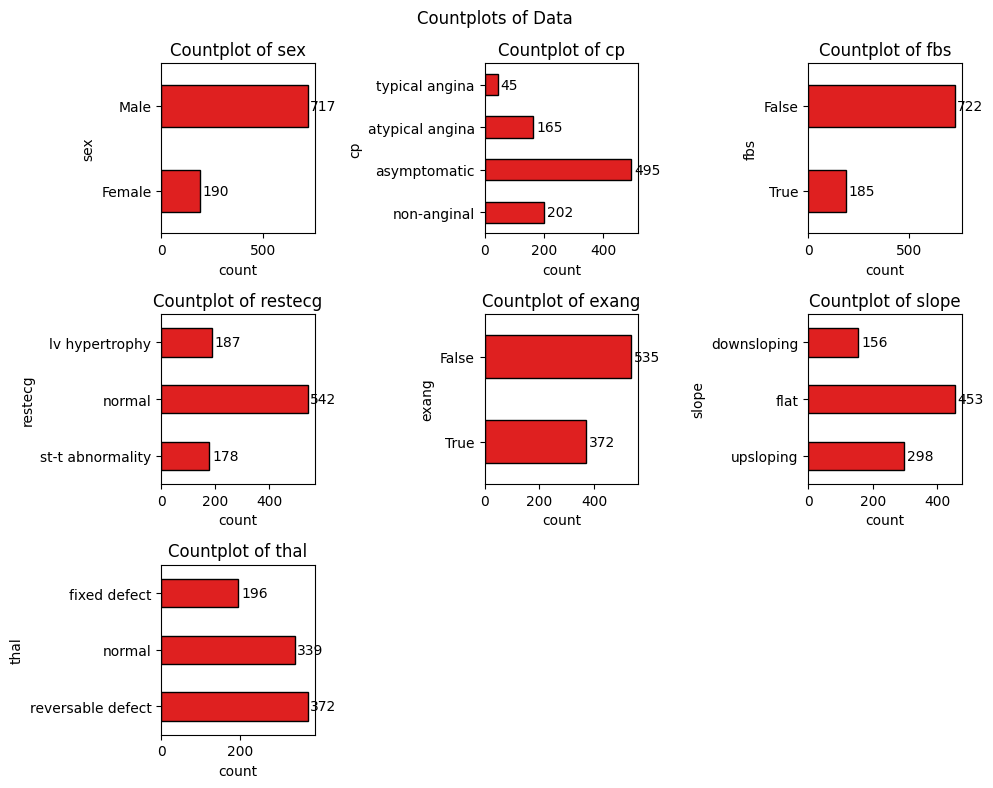

In [25]:
fig,ax = plt.subplots(3,3,figsize=(10,8))

for axis,col in zip(ax.flat,Categorical_cols):
  sns.countplot(data=df,y=col,ax=axis,color="red",width=0.5,edgecolor="black")
  axis.set_title(f"Countplot of {col}")
  axis.set_ylabel(col)

  for container in axis.containers:
    axis.bar_label(container,padding=2)

for axis in ax.flat[len(Categorical_cols):]:
  axis.remove()

plt.suptitle("Countplots of Data")
plt.tight_layout()
plt.show()

### Observation

The categorical variables show noticeable imbalance in several categories. Most observations are Male, asymptomatic chest pain is the most common category, and fbs, restecg, and exang are dominated by specific categories. The slope and thal variables also show uneven category distributions.

## Correlation Analysis

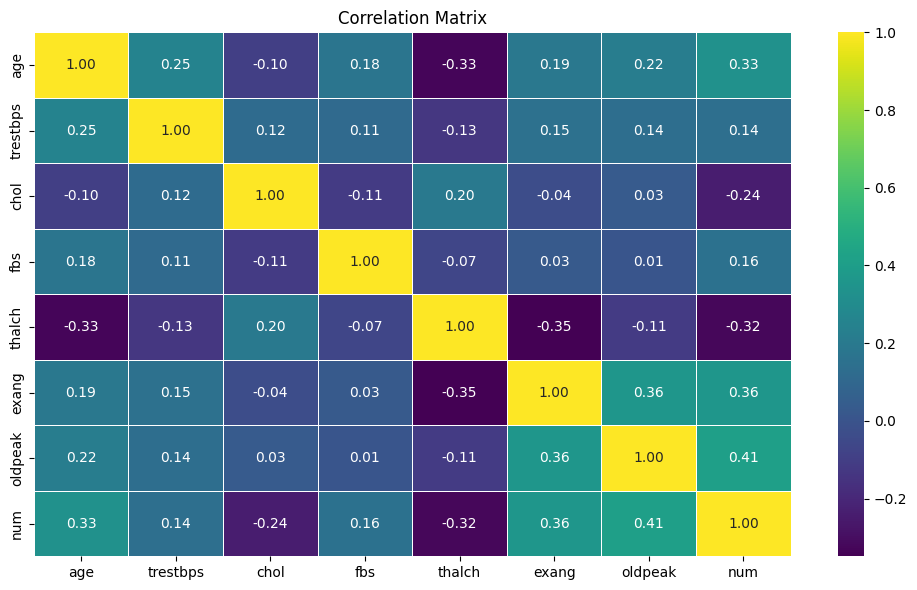

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="viridis",linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation

Most numerical variables have weak to moderate correlations with each other. The target variable num shows its strongest positive correlation with oldpeak (0.41), followed by exang (0.36) and age (0.33), while thalch (-0.32) shows a moderate negative correlation with the target.

# Data Preprocessing

## Feature and Target Separation

In [27]:
X = df.drop(columns = "num")
y = df["num"]

print("X Shape : ",X.shape)
print("y Shape : ",y.shape)

X Shape :  (907, 12)
y Shape :  (907,)


## Encoding Categorical Variables

In [28]:
X = pd.get_dummies(data =X,columns = Categorical_cols, drop_first= True, dtype = int)

## Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, stratify = y, random_state = 42)
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("y_train : ",y_train.shape)
print("y_test : ",y_test.shape)

X_train :  (725, 17)
X_test :  (182, 17)
y_train :  (725,)
y_test :  (182,)


# Decision Tree

In [30]:
model = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [31]:
print("Tree Depth : ",model.get_depth())
print("No.of Leaves : ",model.get_n_leaves())

Tree Depth :  18
No.of Leaves :  287


## Prediction

In [32]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [33]:
comparison_df = pd.DataFrame({"Actual":y_test.values,
                               "Predicted": y_pred})
print("Actual : \n",comparison_df["Actual"].value_counts())
print("Predicted : \n",comparison_df["Predicted"].value_counts())

Actual : 
 Actual
0    80
1    53
2    22
3    21
4     6
Name: count, dtype: int64
Predicted : 
 Predicted
0    72
1    60
3    25
2    20
4     5
Name: count, dtype: int64


## Evaluation Metrics

In [34]:
avg = "weighted"
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred, average = avg)
recall = recall_score(y_test,y_pred, average = avg)
f1 = f1_score(y_test,y_pred, average =avg)
roc_auc = roc_auc_score(y_test,y_prob,multi_class="ovr",average = avg)

Eval_Summary = pd.DataFrame({"Accuracy":[accuracy],"Precision":[precision],
                            "Recall":[recall],"F1":[f1],"ROC-AUC":[roc_auc]})
print(Eval_Summary)

   Accuracy  Precision    Recall        F1   ROC-AUC
0  0.483516   0.495342  0.483516  0.487775  0.647974


## Classification Report

In [35]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.74      0.66      0.70        80
           1       0.42      0.47      0.44        53
           2       0.15      0.14      0.14        22
           3       0.28      0.33      0.30        21
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.32      0.32      0.32       182
weighted avg       0.50      0.48      0.49       182



## Confusion Matrix

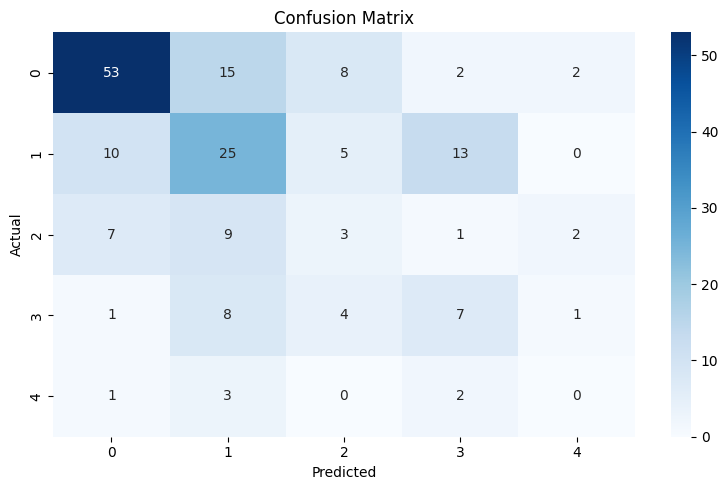

In [36]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (8,5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels = model.classes_,
            yticklabels = model.classes_)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### Observation :

The baseline model correctly predicts many observations from classes 0 and 1, but shows considerable misclassification across the remaining classes. Performance is particularly weak for the minority classes, indicating that the model struggles with class imbalance.

# Hyperparameter Tuning

In [37]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight" : [None,"balanced"]
}

In [38]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_weighted')

In [39]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Score:
0.5246355372367957


# Model Evaluation

In [40]:
# Get the best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred_tuned = best_model.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("Precision:", precision_score(
    y_test, y_pred_tuned, average="weighted", zero_division=0
))

print("Recall:", recall_score(
    y_test, y_pred_tuned, average="weighted", zero_division=0
))

print("F1 Score:", f1_score(
    y_test, y_pred_tuned, average="weighted", zero_division=0
))

Accuracy: 0.5164835164835165
Precision: 0.5354328211471069
Recall: 0.5164835164835165
F1 Score: 0.4699942591345306


In [42]:
print(classification_report(
    y_test,
    y_pred_tuned,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.69      0.78      0.73        80
           1       0.40      0.58      0.48        53
           2       0.00      0.00      0.00        22
           3       1.00      0.05      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.42      0.28      0.26       182
weighted avg       0.54      0.52      0.47       182



In [43]:
print("Tuned Tree Depth:", best_model.get_depth())
print("Number of Leaves:", best_model.get_n_leaves())

Tuned Tree Depth: 3
Number of Leaves: 8


### Observation:
After hyperparameter tuning, the Decision Tree achieved an accuracy of approximately 51.65%, showing a slight improvement over the baseline model. The optimal model used the entropy criterion with a maximum tree depth of 3, resulting in a simpler model with only 8 leaf nodes compared to the deeper baseline tree. However, the model performed significantly better on the majority classes than on minority classes, indicating that class imbalance affected the overall classification performance.

# Comparing Baseline Vs Tuned Model

In [44]:
baseline_metrics = {
    "Model": "Baseline Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )
}

tuned_metrics = {
    "Model": "Tuned Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(
        y_test, y_pred_tuned,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_pred_tuned,
        average="weighted",
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test, y_pred_tuned,
        average="weighted",
        zero_division=0
    )
}

comparison = pd.DataFrame([
    baseline_metrics,
    tuned_metrics
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Decision Tree,0.483516,0.495342,0.483516,0.487775
1,Tuned Decision Tree,0.516484,0.535433,0.516484,0.469994


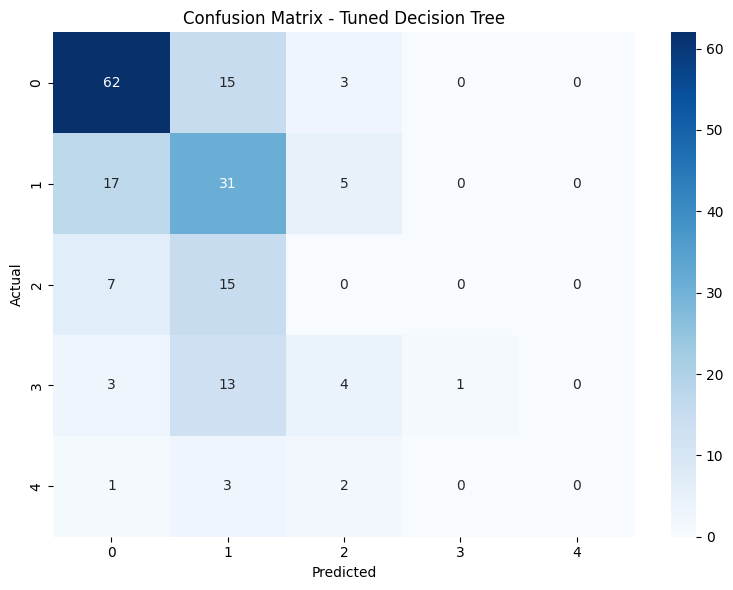

In [45]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Confusion Matrix - Tuned Decision Tree")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## Observation :

The tuned model performs better for the majority classes, especially classes 0 and 1, but fails to correctly identify some minority classes. This indicates that although tuning simplified the model and improved generalization, class imbalance remains a significant challenge.

# Decision Tree Visualization

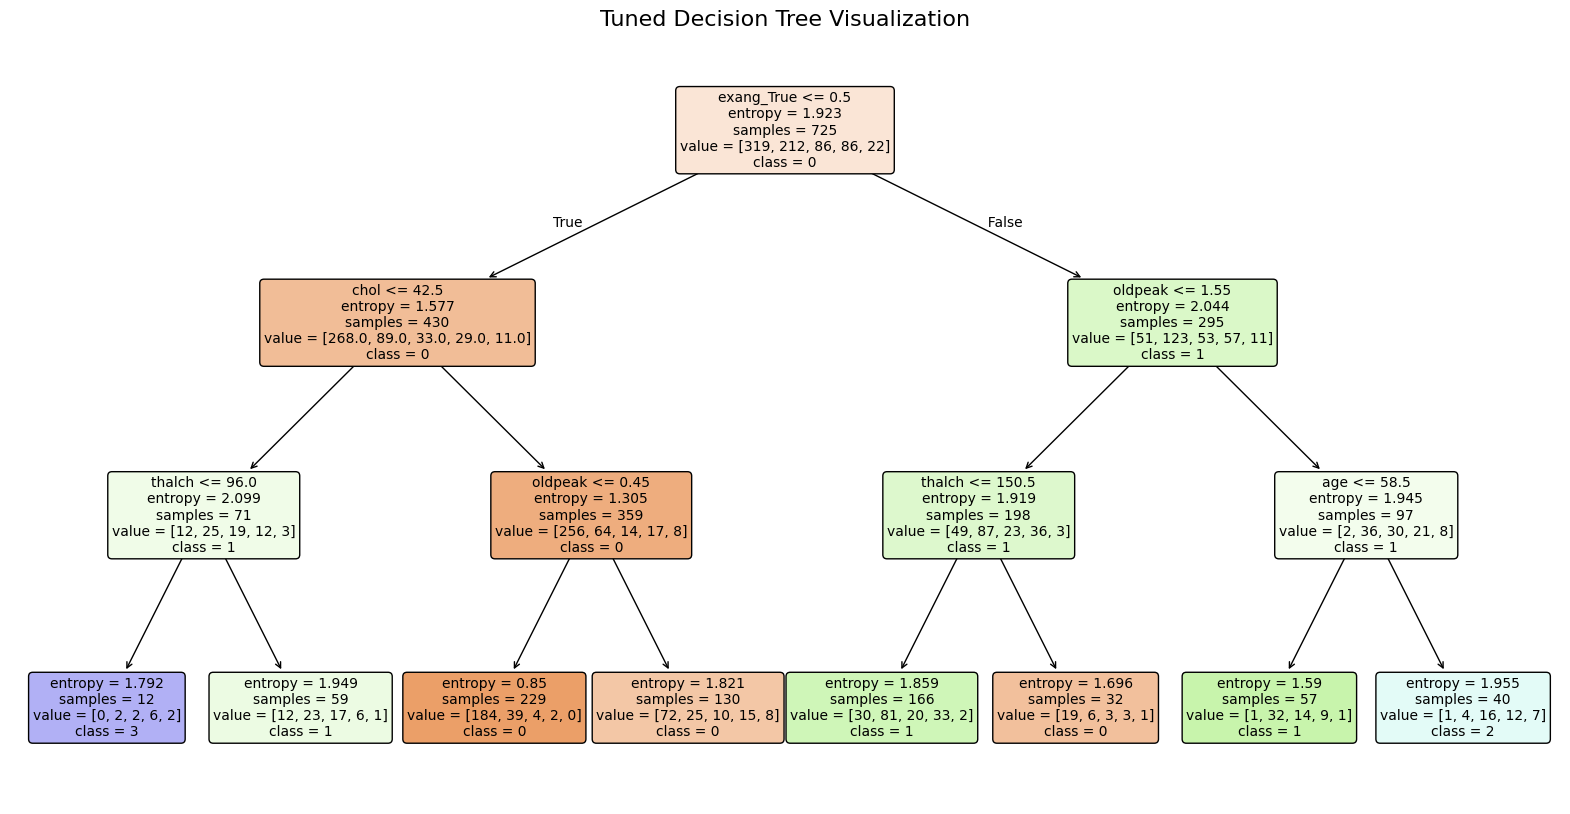

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in best_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tuned Decision Tree Visualization", fontsize=16)

plt.show()

## Observation :

The tuned Decision Tree has a maximum depth of 3, making it simple and interpretable. Features such as exang, chol, oldpeak, thalch, and age are used to split the data, showing their importance in the model's classification decisions.

# Feature Importance Analysis

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,exang_True,0.382673
4,oldpeak,0.242180
2,chol,0.207053
3,thalch,0.100838
0,age,0.067256
5,sex_Male,0.000000
6,cp_atypical angina,0.000000
7,cp_non-anginal,0.000000
1,trestbps,0.000000
8,cp_typical angina,0.000000


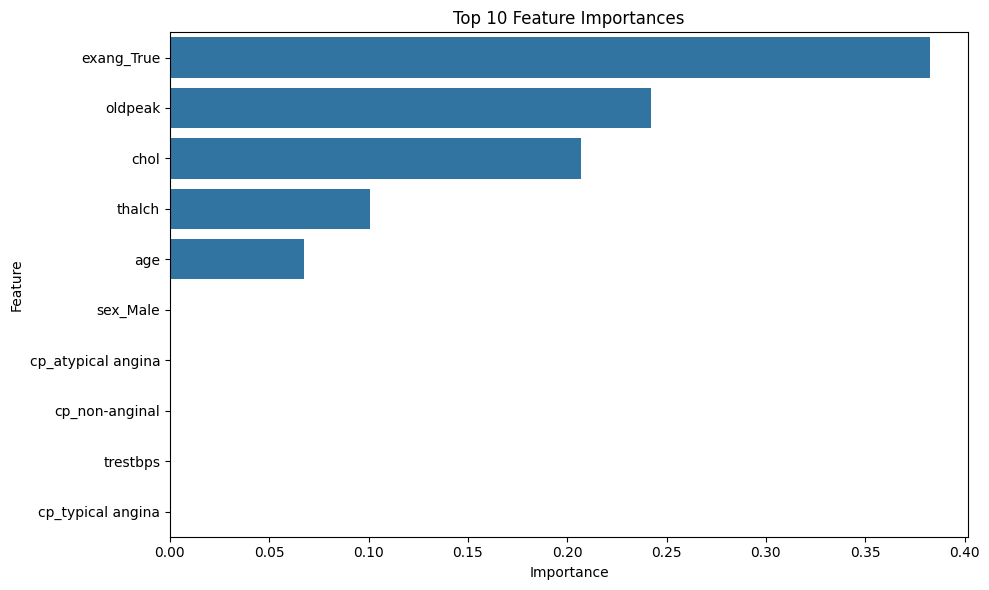

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.tight_layout()
plt.show()

## Observation:
exang is the most important feature for the tuned Decision Tree, followed by oldpeak and chol. Features such as thalch and age also contribute to the model, while several other features have zero importance because they were not used for splitting in the final tree.

# CONCLUSION

The Decision Tree Classification model was successfully implemented on the dataset after performing data cleaning, missing value handling, exploratory data analysis, categorical feature encoding, and train-test splitting.

The baseline Decision Tree produced a highly complex model with a depth of 18 and 250 leaf nodes, indicating a high possibility of overfitting. Hyperparameter tuning using GridSearchCV identified Entropy as the best criterion with a maximum depth of 3.

The tuned Decision Tree achieved an accuracy of approximately 51.65% and produced a much simpler model with only 8 leaf nodes. Although the tuned model showed a slight improvement in overall accuracy and reduced model complexity, it performed poorly on some minority classes, indicating the impact of class imbalance.

Feature importance analysis identified the most influential features used by the Decision Tree for classification. Overall, hyperparameter tuning helped create a simpler and more interpretable model while slightly improving its generalization performance.

# Interview Questions

## 1. What are some common hyperparameters of Decision Tree models, and how do they affect performance?

Common hyperparameters include:

- **criterion:** Determines how the quality of a split is measured, such as gini or entropy.
- **max_depth:** Limits the maximum depth of the tree. Lower values help reduce overfitting.
- **min_samples_split:** Minimum number of samples required to split a node. Higher values create a simpler tree.
- **min_samples_leaf:** Minimum number of samples required in a leaf node. Increasing it can reduce overfitting.
- **max_features:** Controls the number of features considered when searching for the best split.

These hyperparameters control the complexity of the Decision Tree and help balance underfitting and overfitting.

## 2. What is the difference between Label Encoding and One-Hot Encoding?

### Label Encoding

Label Encoding converts categorical values into numerical values.

**Example:**

| Category | Encoded Value |
|----------|---------------|
| Low | 0 |
| Medium | 1 |
| High | 2 |

Label Encoding is generally suitable for **ordinal categorical variables**, where a natural order exists.

### One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category.

**Example:**

| Color | Color_Red | Color_Blue | Color_Green |
|-------|-----------|------------|-------------|
| Red | 1 | 0 | 0 |
| Blue | 0 | 1 | 0 |
| Green | 0 | 0 | 1 |

One-Hot Encoding is generally suitable for **nominal categorical variables**, where no natural order exists.

### Key Difference

> **Label Encoding** represents categories using a single numerical column, whereas **One-Hot Encoding** creates separate binary columns for each category.